#  Сегментация изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* https://www.kaggle.com/datasets/rajkumarl/people-clothing-segmentation/data
* https://pyimagesearch.com/2021/11/08/u-net-training-image-segmentation-models-in-pytorch/
* https://amaarora.github.io/posts/2020-09-13-unet.html
* https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html
* https://medium.com/apache-mxnet/transposed-convolutions-explained-with-ms-excel-52d13030c7e8
* https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md
* https://huggingface.co/docs/transformers/model_doc/segformer
* https://www.kaggle.com/code/damianpanek/segformerb0-people-clothing-segmentation

In [1]:
# Используемые библиотеки
import os
import io
import sys
import zipfile
import tempfile
import random
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", DEVICE)


Устройство: cuda


## Задачи для совместного разбора

1\. Обсудите постановку задачи сегментации изображений.

2\. Рассмотрите пример работы слоя `ConvTranspose2d`.

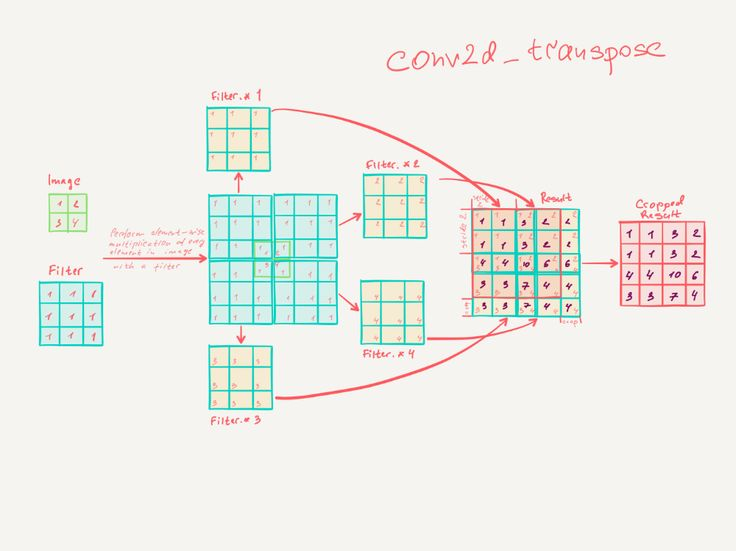

In [2]:
# Входной тензор
x = torch.tensor([[[[1., 2.],
                    [3., 4.]]]])

print("=== АНАЛИЗ ConvTranspose2d ===")
print("Входной тензор:")
print(x.squeeze().numpy())
print("Размер:", tuple(x.shape))

conv_transpose = nn.ConvTranspose2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=1,
    bias=False,
)

with torch.no_grad():
    conv_transpose.weight.fill_(1.0)

output = conv_transpose(x)

print("\nЯдро:")
print(conv_transpose.weight.detach().squeeze().numpy())
print("\nВыходной тензор:")
print(output.detach().squeeze().numpy())
print("Размер:", tuple(output.shape))

# Формула:
# H_out = (H_in - 1) * stride - 2*padding
#         + dilation*(kernel_size - 1) + output_padding + 1
H_in = x.shape[-2]
stride = conv_transpose.stride[0]
padding = conv_transpose.padding[0]
kernel_size = conv_transpose.kernel_size[0]
output_padding = conv_transpose.output_padding[0]
dilation = conv_transpose.dilation[0]

H_out = (
    (H_in - 1) * stride
    - 2 * padding
    + dilation * (kernel_size - 1)
    + output_padding
    + 1
)

print(
    f"\nПроверка размера: ({H_in}-1)*{stride} - 2*{padding} "
    f"+ {dilation}*({kernel_size}-1) + {output_padding} + 1 = {H_out}"
)
assert output.shape[-2] == H_out and output.shape[-1] == H_out


=== АНАЛИЗ ConvTranspose2d ===
Входной тензор:
[[1. 2.]
 [3. 4.]]
Размер: (1, 1, 2, 2)

Ядро:
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Выходной тензор:
[[ 1.  3.  2.  2.]
 [ 4. 10.  6.  6.]
 [ 3.  7.  4.  4.]
 [ 3.  7.  4.  4.]]
Размер: (1, 1, 4, 4)

Проверка размера: (2-1)*2 - 2*1 + 1*(3-1) + 1 + 1 = 4


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Опишите датасет `ClothesSegmentationDataset`. Реализуйте `__getitem__` таким образом, чтобы он возвращал два элемента: тензор с изображением и тензор с маской. Маска должна быть представлена трехмерным тензором целых чисел. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений и масок. Создайте объект датасета и выведите на экран форму и типы одного изображения и его маски.

- [ ] Проверено на семинаре

In [3]:
class ClothesSegmentationDataset(Dataset):
    """
    Датасет для пар изображение/маска, расположенных в двух директориях.

    Возвращает:
      image: FloatTensor [3, H, W]
      mask:  LongTensor  [1, H, W]
    """

    def __init__(self, images_dir, masks_dir, transform=None, mask_transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.transform = transform
        self.mask_transform = mask_transform

        image_files = [
            p for p in self.images_dir.iterdir()
            if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
        ]
        mask_files = [
            p for p in self.masks_dir.iterdir()
            if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
        ]

        def sample_id(path):
            # Работает и для "123.jpg", и для маски "123.jpg.png".
            return path.name.split(".")[0]

        images_by_id = {sample_id(p): p for p in image_files}
        masks_by_id = {sample_id(p): p for p in mask_files}
        common_ids = sorted(set(images_by_id) & set(masks_by_id))

        if not common_ids:
            raise ValueError("Не найдено ни одной пары изображение-маска")

        self.pairs = [(images_by_id[k], masks_by_id[k]) for k in common_ids]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        if self.mask_transform is not None:
            mask = self.mask_transform(mask)
        else:
            mask_array = np.asarray(mask)
            if mask_array.ndim == 3:
                mask_array = mask_array[..., 0]
            mask = torch.from_numpy(mask_array.copy()).long().unsqueeze(0)

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        if mask.ndim != 3:
            raise ValueError(f"Маска должна быть 3D, получено shape={tuple(mask.shape)}")

        return image.float(), mask.long()


In [4]:
class MaskTransform:
    """
    Преобразование маски в LongTensor [1,H,W].

    Для масок из People Clothing Segmentation:
      1) вырезает полезную RGBA-область по alpha>0;
      2) восстанавливает 16 class_id по уровням 0,17,...,255;
      3) resize выполняется только методом NEAREST.
    """

    def __init__(self, size=(256, 256), n_classes=16, gray_step=17.0):
        self.size = tuple(size)
        self.n_classes = int(n_classes)
        self.gray_step = float(gray_step)
        self._resampling = Image.Resampling if hasattr(Image, "Resampling") else Image

    def __call__(self, mask):
        if not isinstance(mask, Image.Image):
            mask = Image.fromarray(np.asarray(mask))

        arr = np.asarray(mask)

        if arr.ndim == 3 and arr.shape[2] == 4 and np.any(arr[..., 3] == 0):
            # Реальная RGBA-маска из archive.zip.
            rgba = np.asarray(mask.convert("RGBA"))
            alpha = rgba[..., 3] > 0
            ys, xs = np.where(alpha)
            if len(xs) == 0:
                raise ValueError("Пустая alpha-маска")
            y0, y1 = ys.min(), ys.max() + 1
            x0, x1 = xs.min(), xs.max() + 1
            gray = rgba[y0:y1, x0:x1, 0].astype(np.float32)
            labels = np.rint(gray / self.gray_step)
            labels = np.clip(labels, 0, self.n_classes - 1).astype(np.uint8)
            mask = Image.fromarray(labels, mode="L")
        else:
            # Обычная уже дискретная маска.
            if mask.mode not in ("L", "P", "I", "I;16"):
                mask = mask.convert("L")

        mask = mask.resize(self.size, self._resampling.NEAREST)
        mask_array = np.asarray(mask, dtype=np.int64).copy()
        return torch.from_numpy(mask_array).long().unsqueeze(0)


image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
mask_transform = MaskTransform((256, 256))


archives_here = [
    p for p in [ Path("archive_clothes.zip")]
    if p.exists()
]
if not archives_here:
    archives_here = sorted(Path(".").glob("*.zip"))

if archives_here:
    task1_zip = archives_here[0]
    demo_root = Path(tempfile.mkdtemp(prefix="clothes_seg_real_"))
    demo_images = demo_root / "images"
    demo_masks = demo_root / "masks"
    demo_images.mkdir()
    demo_masks.mkdir()

    with zipfile.ZipFile(task1_zip, "r") as zf:
        image_members = sorted(
            f for f in zf.namelist()
            if f.startswith("Train/Image/") and f.lower().endswith((".jpg", ".jpeg", ".png"))
        )[:8]

        for image_member in image_members:
            sample_id = Path(image_member).name.split(".")[0]
            mask_member = f"Train/Mask/{sample_id}.jpg.png"
            if mask_member not in zf.namelist():
                continue
            (demo_images / Path(image_member).name).write_bytes(zf.read(image_member))
            (demo_masks / Path(mask_member).name).write_bytes(zf.read(mask_member))

    demo_dataset = ClothesSegmentationDataset(
        demo_images,
        demo_masks,
        transform=image_transform,
        mask_transform=mask_transform,
    )
    print("Задание 1 использует реальные пары из:", task1_zip)
else:
    # Fallback только если архив не был приложен.
    demo_root = Path(tempfile.mkdtemp(prefix="clothes_seg_demo_"))
    demo_images = demo_root / "images"
    demo_masks = demo_root / "masks"
    demo_images.mkdir()
    demo_masks.mkdir()

    for i in range(3):
        img = np.zeros((180, 240, 3), dtype=np.uint8)
        img[..., 0] = 70 + i * 50
        img[..., 1] = np.linspace(0, 255, 240, dtype=np.uint8)
        Image.fromarray(img).save(demo_images / f"{i}.jpg")

        mask = np.zeros((180, 240), dtype=np.uint8)
        mask[30:120, 40:120] = 1
        mask[70:160, 130:220] = 2
        Image.fromarray(mask).save(demo_masks / f"{i}.png")

    demo_dataset = ClothesSegmentationDataset(
        demo_images,
        demo_masks,
        transform=image_transform,
        mask_transform=MaskTransform((256, 256), n_classes=16),
    )
    print("Архив не найден: для задания 1 используется демонстрационный fallback.")


demo_image, demo_mask = demo_dataset[0]
print("Размер датасета:", len(demo_dataset))
print("Изображение:", tuple(demo_image.shape), demo_image.dtype)
print("Маска:", tuple(demo_mask.shape), demo_mask.dtype)
print("Классы в примере:", torch.unique(demo_mask).tolist())

assert demo_image.ndim == 3
assert demo_mask.ndim == 3
assert demo_mask.dtype == torch.long


Задание 1 использует реальные пары из: archive_clothes.zip
Размер датасета: 8
Изображение: (3, 256, 256) torch.float32
Маска: (1, 256, 256) torch.int64
Классы в примере: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


<p class="task" id="2"></p>

2\. Напишите функцию `show_image_with_mask`, которая выводит рядом два изображения: фотографию и маску. Продемонстрируйте работу функции, взяв один пример из созданного датасета.

- [ ] Проверено на семинаре

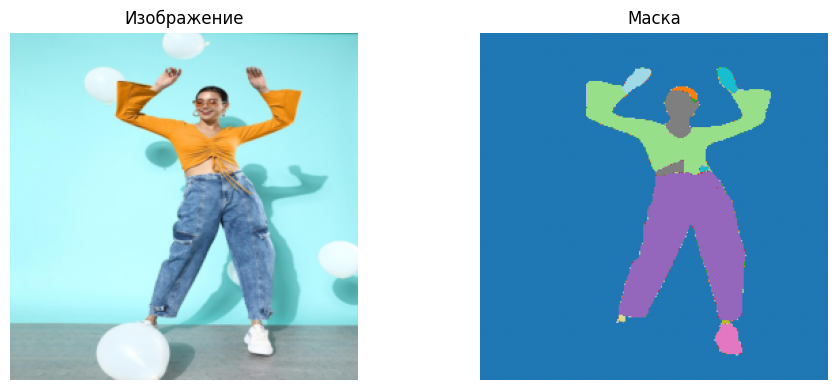

In [5]:
def show_image_with_mask(image, mask, title_image="Изображение", title_mask="Маска"):
    """Выводит рядом изображение и соответствующую маску сегментации."""
    if isinstance(image, torch.Tensor):
        image_np = image.detach().cpu()
        if image_np.ndim == 4:
            image_np = image_np[0]
        image_np = image_np.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0, 1)
    else:
        image_np = np.asarray(image)

    if isinstance(mask, torch.Tensor):
        mask_np = mask.detach().cpu().squeeze().numpy()
    else:
        mask_np = np.asarray(mask).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image_np)
    axes[0].set_title(title_image)
    axes[0].axis("off")

    vmax = max(int(np.max(mask_np)), 1)
    axes[1].imshow(mask_np, cmap="tab20", vmin=0, vmax=vmax)
    axes[1].set_title(title_mask)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


show_image_with_mask(demo_image, demo_mask)

In [6]:
def _zip_has_clothes_structure(zip_path):
    """Проверяет, что ZIP действительно содержит Train/Image и Train/Mask."""
    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            names = [n.replace("\\", "/").lower() for n in zf.namelist() if not n.endswith("/")]
        has_train_images = any(n.startswith("train/image/") for n in names)
        has_train_masks = any(n.startswith("train/mask/") and n.endswith(".png") for n in names)
        return has_train_images and has_train_masks
    except (zipfile.BadZipFile, OSError):
        return False


def find_archive():
    """
    Ищет именно People Clothing Segmentation архив.
    Имя файла не важно: проверяется внутренняя структура ZIP.
    """
    preferred = [
        "archive_clothes.zip",
        "archive (1).zip",
        "archive.zip",
    ]

    candidates = []
    for name in preferred:
        p = Path(name)
        if p.exists():
            candidates.append(p)

    # Добавляем остальные ZIP, не дублируя уже найденные.
    for p in sorted(Path(".").glob("*.zip")):
        if p not in candidates:
            candidates.append(p)

    for p in candidates:
        if _zip_has_clothes_structure(p):
            return str(p)

    return None


def explore_zip_structure(zip_path, max_files=12):
    """Показывает реальную структуру архива и число корректных пар Image/Mask."""
    if zip_path is None:
        print(
            "Архив People Clothing Segmentation не найден. "
            "Положите archive_clothes.zip (или другой ZIP с Train/Image и Train/Mask) рядом с ноутбуком."
        )
        return

    with zipfile.ZipFile(zip_path, "r") as zf:
        files = [f for f in zf.namelist() if not f.endswith("/")]

    def ids_for(split, folder):
        prefix = f"{split}/{folder}/".lower()
        return {
            Path(f).name.split(".")[0]
            for f in files
            if f.replace("\\", "/").lower().startswith(prefix)
            and (
                folder.lower() != "mask"
                or f.replace("\\", "/").lower().endswith(".png")
            )
        }

    print("Архив:", zip_path)
    print("Всего файлов:", len(files))
    for split in ("Train", "Test"):
        image_ids = ids_for(split, "Image")
        mask_ids = ids_for(split, "Mask")
        print(
            f"{split}: images={len(image_ids)}, masks={len(mask_ids)}, "
            f"корректных пар={len(image_ids & mask_ids)}"
        )

    print("Первые файлы:")
    for f in files[:max_files]:
        print(" ", f)


ARCHIVE_PATH = find_archive()
explore_zip_structure(ARCHIVE_PATH)

Архив: archive_clothes.zip
Всего файлов: 618
Train: images=192, masks=192, корректных пар=192
Test: images=10, masks=10, корректных пар=10
Первые файлы:
  Test/Image/13358.jpg
  Test/Image/1876.jpg
  Test/Image/3729.jpg
  Test/Image/4116.jpg
  Test/Image/4959.jpg
  Test/Image/5043.jpg
  Test/Image/5258.jpg
  Test/Image/8237.jpg
  Test/Image/8474.jpg
  Test/Image/8725.jpg
  Test/Mask/13358.jpg.png
  Test/Mask/1876.jpg.png


Train: найдено 192 пар | n_classes=16 | size=(128, 128)
Test: найдено 10 пар | n_classes=16 | size=(128, 128)
Изображение: (3, 128, 128) torch.float32
Маска: (1, 128, 128) torch.int64
Классы в примере: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего семантических классов: 16


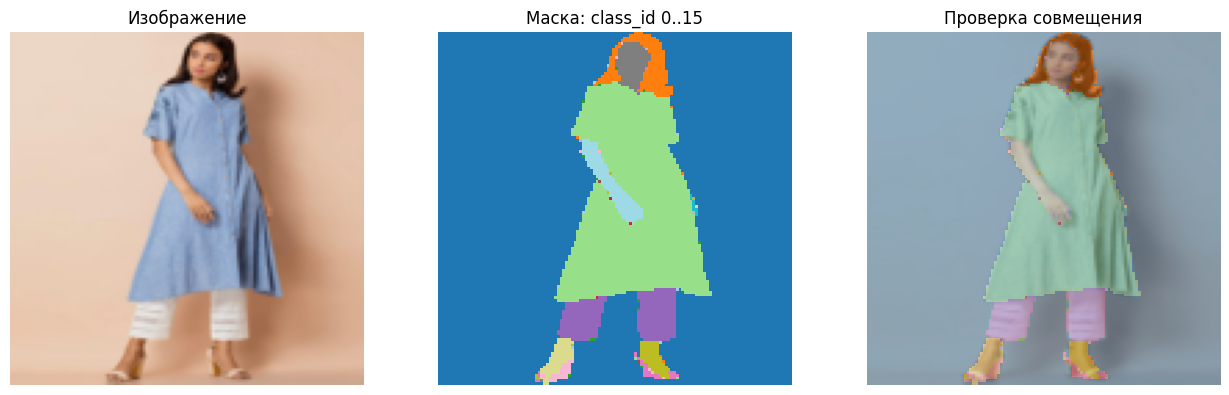

In [7]:
class ArchiveClothesSegmentationDataset(Dataset):
    """
    Датасет для конкретного People Clothing Segmentation archive.zip.

    В архиве изображения и маски имеют разную геометрию:
      Image: RGB 1080x1440
      Mask:  RGBA 1920x1440

    Полезная область маски находится внутри alpha>0 и имеет то же
    соотношение сторон, что исходная фотография. Семантические классы
    закодированы 16 уровнями серого: 0, 17, 34, ..., 255.
    Промежуточные значения на границах являются следствием интерполяции,
    поэтому class_id восстанавливается округлением gray / 17.

    Возвращает:
      image: FloatTensor [3, H, W] в диапазоне [0, 1]
      mask:  LongTensor  [1, H, W] с class_id 0..15
    """

    N_CLASSES = 16
    GRAY_STEP = 17.0

    def __init__(self, zip_path, split="Train", image_size=(128, 128), cache=True):
        self.zip_path = str(zip_path)
        self.split = str(split)
        self.image_size = tuple(image_size)
        self.cache = bool(cache)
        self._cache = {}
        self._resampling = Image.Resampling if hasattr(Image, "Resampling") else Image

        with zipfile.ZipFile(self.zip_path, "r") as zf:
            files = [f for f in zf.namelist() if not f.endswith("/")]

        self.pairs = self._pair_files(files)
        if not self.pairs:
            raise ValueError(f"В split={self.split!r} не найдены пары Image/Mask")

        self.n_classes = self.N_CLASSES
        self.class_values = list(range(self.N_CLASSES))

        print(
            f"{self.split}: найдено {len(self.pairs)} пар | "
            f"n_classes={self.n_classes} | size={self.image_size}"
        )

    @staticmethod
    def _sample_id(filename):
        # 10223.jpg и 10223.jpg.png -> один ID 10223
        return Path(filename).name.split(".")[0]

    def _pair_files(self, files):
        prefix = self.split.lower() + "/"
        images = {}
        masks = {}

        for f in files:
            normalized = f.replace("\\", "/")
            low = normalized.lower()
            if not low.startswith(prefix):
                continue

            sample_id = self._sample_id(normalized)
            if "/image/" in low and Path(normalized).suffix.lower() in {".jpg", ".jpeg", ".png"}:
                images[sample_id] = normalized
            elif "/mask/" in low and low.endswith(".png"):
                # В архиве встречаются служебные дубликаты; для маски берём PNG.
                masks[sample_id] = normalized

        common = sorted(
            set(images) & set(masks),
            key=lambda x: int(x) if x.isdigit() else x,
        )
        return [(images[k], masks[k]) for k in common]

    def _read_pil(self, member):
        with zipfile.ZipFile(self.zip_path, "r") as zf:
            return Image.open(io.BytesIO(zf.read(member))).copy()

    @classmethod
    def _decode_rgba_mask(cls, mask):
        """RGBA mask -> 2D uint8 class ids 0..15 до resize."""
        rgba = np.asarray(mask.convert("RGBA"))
        alpha = rgba[..., 3] > 0
        if not alpha.any():
            raise ValueError("У маски отсутствует непрозрачная область (alpha>0)")

        ys, xs = np.where(alpha)
        y0, y1 = int(ys.min()), int(ys.max()) + 1
        x0, x1 = int(xs.min()), int(xs.max()) + 1

        # Каналы RGB у этих масок являются оттенками серого.
        gray = rgba[y0:y1, x0:x1, 0].astype(np.float32)
        class_ids = np.rint(gray / cls.GRAY_STEP)
        class_ids = np.clip(class_ids, 0, cls.N_CLASSES - 1).astype(np.uint8)
        return class_ids

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        if self.cache and idx in self._cache:
            return self._cache[idx]

        image_member, mask_member = self.pairs[idx]
        image = self._read_pil(image_member).convert("RGB")
        raw_mask = self._read_pil(mask_member)

        # Mask: alpha-crop -> восстановление class_id -> NEAREST resize.
        class_ids = self._decode_rgba_mask(raw_mask)
        class_mask = Image.fromarray(class_ids, mode="L")

        image = image.resize(self.image_size, self._resampling.BILINEAR)
        class_mask = class_mask.resize(self.image_size, self._resampling.NEAREST)

        image_tensor = transforms.ToTensor()(image).float()
        mask_array = np.asarray(class_mask, dtype=np.int64).copy()
        mask_tensor = torch.from_numpy(mask_array).long().unsqueeze(0)

        result = (image_tensor, mask_tensor)
        if self.cache:
            self._cache[idx] = result
        return result


def show_archive_example(dataset, idx=0):
    image, mask = dataset[idx]
    image_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze(0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Изображение")
    axes[1].imshow(mask_np, cmap="tab20", vmin=0, vmax=dataset.n_classes - 1,
                   interpolation="nearest")
    axes[1].set_title("Маска: class_id 0..15")
    axes[2].imshow(image_np)
    axes[2].imshow(mask_np, cmap="tab20", vmin=0, vmax=dataset.n_classes - 1,
                   alpha=0.45, interpolation="nearest")
    axes[2].set_title("Проверка совмещения")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


if ARCHIVE_PATH is not None:
    archive_train_dataset = ArchiveClothesSegmentationDataset(
        ARCHIVE_PATH, split="Train", image_size=(128, 128)
    )
    archive_test_dataset = ArchiveClothesSegmentationDataset(
        ARCHIVE_PATH, split="Test", image_size=(128, 128)
    )
    # Имя оставлено для совместимости со следующими ячейками.
    archive_dataset = archive_train_dataset

    real_image, real_mask = archive_train_dataset[0]
    print("Изображение:", tuple(real_image.shape), real_image.dtype)
    print("Маска:", tuple(real_mask.shape), real_mask.dtype)
    print("Классы в примере:", torch.unique(real_mask).tolist())
    print("Всего семантических классов:", archive_train_dataset.n_classes)
    show_archive_example(archive_train_dataset, 0)
else:
    archive_train_dataset = archive_test_dataset = archive_dataset = None
    print("Архив People Clothing Segmentation не найден. Добавьте ZIP с Train/Image и Train/Mask рядом с ноутбуком.")


<p class="task" id="3"></p>

3\. Реализуйте архитектуру U-Net. Реализуйте модель таким образом, чтобы на выходе для каждого изображения получался тензор размера `n_classes x h x w`, где `n_classes` - количество уникальных значений в масках, а `h` и `w` - размер исходного изображения. Возьмите один пример из набора данных и пропустите его через сеть. Выведите форму полученного результата на экран.

- [ ] Проверено на семинаре

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """Классическая U-Net с skip connections."""

    def __init__(self, n_channels=3, n_classes=2, base_channels=32):
        super().__init__()

        b = base_channels

        self.enc1 = DoubleConv(n_channels, b)
        self.enc2 = DoubleConv(b, b * 2)
        self.enc3 = DoubleConv(b * 2, b * 4)
        self.enc4 = DoubleConv(b * 4, b * 8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(b * 8, b * 16)

        self.up4 = nn.ConvTranspose2d(b * 16, b * 8, 2, stride=2)
        self.dec4 = DoubleConv(b * 16, b * 8)

        self.up3 = nn.ConvTranspose2d(b * 8, b * 4, 2, stride=2)
        self.dec3 = DoubleConv(b * 8, b * 4)

        self.up2 = nn.ConvTranspose2d(b * 4, b * 2, 2, stride=2)
        self.dec2 = DoubleConv(b * 4, b * 2)

        self.up1 = nn.ConvTranspose2d(b * 2, b, 2, stride=2)
        self.dec1 = DoubleConv(b * 2, b)

        self.out = nn.Conv2d(b, n_classes, kernel_size=1)

    @staticmethod
    def _match_size(x, reference):
        if x.shape[-2:] != reference.shape[-2:]:
            x = F.interpolate(
                x,
                size=reference.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )
        return x

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self._match_size(self.up4(b), e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self._match_size(self.up3(d4), e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self._match_size(self.up2(d3), e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self._match_size(self.up1(d2), e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)


In [9]:
# Проверка U-Net на одном реальном примере.
dataset_for_unet = archive_train_dataset if archive_train_dataset is not None else demo_dataset
sample_image, sample_mask = dataset_for_unet[0]

if hasattr(dataset_for_unet, "n_classes"):
    n_classes = dataset_for_unet.n_classes
else:
    n_classes = int(sample_mask.max().item()) + 1

unet = UNet(n_channels=3, n_classes=n_classes, base_channels=16)

with torch.no_grad():
    logits = unet(sample_image.unsqueeze(0))

expected = (1, n_classes, sample_image.shape[-2], sample_image.shape[-1])
print("n_classes:", n_classes)
print("Вход:", tuple(sample_image.unsqueeze(0).shape))
print("Выход:", tuple(logits.shape))
print("Ожидаемый формат:", expected)

assert tuple(logits.shape) == expected


n_classes: 16
Вход: (1, 3, 128, 128)
Выход: (1, 16, 128, 128)
Ожидаемый формат: (1, 16, 128, 128)


<p class="task" id="4"></p>

4\.  Разбейте набор данных на обучающее и валидационное множество. Обучите модель U-Net для сегментации изображения. Во время обучения выводите на экран значения функции потерь и точности прогнозов на обучающем и валидационном множестве. Обратите внимание, что выборка является несбалансированной. При расчете функции потерь примените любую известную вам технику для работы с несбалансированными выборками.

При создании датасета допускается использовать преобразования, уменьшающие размер изображений (для ускорения процесса обучения).

Используя обученную модель, получите предсказания для нескольких изображений и отрисуйте их.
- [ ] Проверено на семинаре

Доля пикселей по классам: [0.62078, 0.00101, 0.02009, 0.00077, 0.11217, 0.03169, 0.06153, 0.06388, 0.00561, 0.00298, 0.00795, 0.02114, 0.00721, 0.00954, 0.01482, 0.01884]
Веса классов: [0.25, 2.806, 0.628, 3.214, 0.266, 0.5, 0.359, 0.352, 1.188, 1.629, 0.997, 0.612, 1.048, 0.911, 0.731, 0.648]
Epoch 01/8 | train loss=2.5478, acc=0.1841, mIoU=0.0273 | val loss=2.4051, acc=0.5996, mIoU=0.0380
Epoch 02/8 | train loss=2.2727, acc=0.4812, mIoU=0.0631 | val loss=2.2546, acc=0.5695, mIoU=0.0682
Epoch 03/8 | train loss=2.0661, acc=0.5567, mIoU=0.0853 | val loss=2.3018, acc=0.5033, mIoU=0.0690
Epoch 04/8 | train loss=1.8802, acc=0.6196, mIoU=0.0996 | val loss=1.8751, acc=0.6750, mIoU=0.1029
Epoch 05/8 | train loss=1.7413, acc=0.6501, mIoU=0.1053 | val loss=1.8908, acc=0.6404, mIoU=0.0935
Epoch 06/8 | train loss=1.6498, acc=0.6585, mIoU=0.1084 | val loss=1.7907, acc=0.6620, mIoU=0.1151
Epoch 07/8 | train loss=1.5627, acc=0.6856, mIoU=0.1188 | val loss=1.6623, acc=0.6778, mIoU=0.1095
Epoch 08/8 |

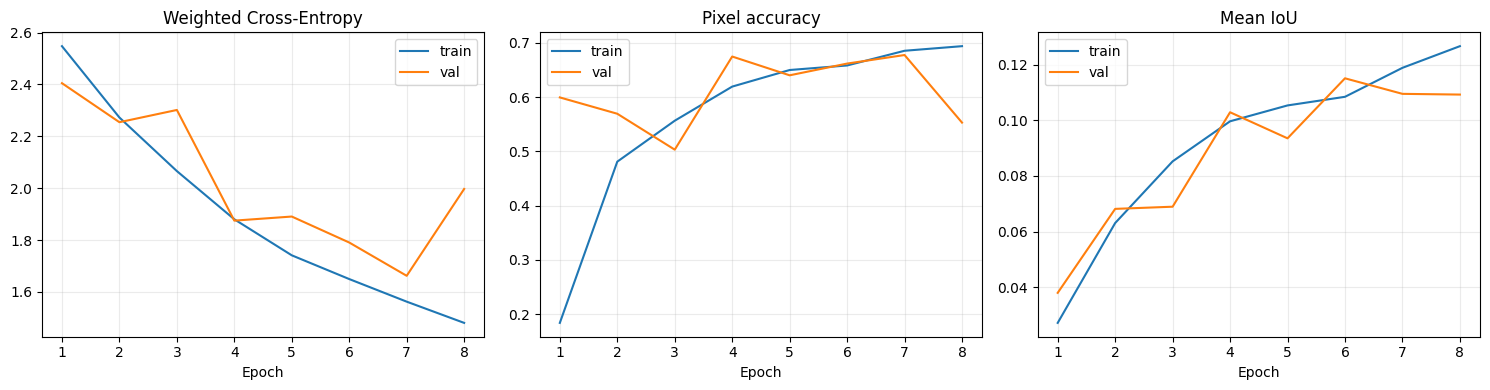

In [10]:
def squeeze_masks(masks):
    if masks.ndim == 4 and masks.shape[1] == 1:
        masks = masks[:, 0]
    return masks.long()


def confusion_matrix_from_batch(preds, targets, n_classes):
    valid = (targets >= 0) & (targets < n_classes)
    encoded = n_classes * targets[valid] + preds[valid]
    hist = torch.bincount(encoded, minlength=n_classes ** 2)
    return hist.reshape(n_classes, n_classes).cpu().double()


def metrics_from_confusion(conf):
    total = conf.sum().clamp_min(1)
    accuracy = conf.diag().sum() / total

    union = conf.sum(1) + conf.sum(0) - conf.diag()
    valid = union > 0
    iou = torch.zeros_like(union)
    iou[valid] = conf.diag()[valid] / union[valid]
    miou = iou[valid].mean() if valid.any() else torch.tensor(0.0)
    return float(accuracy), float(miou)


def compute_class_weights(dataset, indices, n_classes):
    """Inverse-sqrt frequency + clipping: устойчиво для редких классов."""
    counts = torch.zeros(n_classes, dtype=torch.float64)
    for idx in indices:
        _, mask = dataset[idx]
        counts += torch.bincount(mask.flatten(), minlength=n_classes).double()

    freq = counts / counts.sum().clamp_min(1)
    weights = 1.0 / torch.sqrt(freq.clamp_min(1e-8))
    weights[counts == 0] = 0.0
    positive = weights > 0
    weights[positive] /= weights[positive].mean()
    weights = weights.clamp(0.25, 4.0)

    print("Доля пикселей по классам:", [round(float(x), 5) for x in freq])
    return weights.float()


def run_unet_epoch(model, loader, criterion, device, n_classes, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    conf = torch.zeros((n_classes, n_classes), dtype=torch.float64)

    for images, masks in loader:
        images = images.to(device)
        targets = squeeze_masks(masks).to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, targets)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        conf += confusion_matrix_from_batch(preds, targets, n_classes)

    acc, miou = metrics_from_confusion(conf)
    return total_loss / len(loader.dataset), acc, miou


def train_unet_model(model, train_loader, val_loader, class_weights, epochs=8, lr=1e-3):
    model = model.to(DEVICE)
    n_classes = model.out.out_channels
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {k: [] for k in (
        "train_loss", "val_loss", "train_acc", "val_acc", "train_miou", "val_miou"
    )}
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_miou = run_unet_epoch(
            model, train_loader, criterion, DEVICE, n_classes, optimizer
        )
        with torch.no_grad():
            val_loss, val_acc, val_miou = run_unet_epoch(
                model, val_loader, criterion, DEVICE, n_classes
            )

        for key, value in {
            "train_loss": train_loss, "val_loss": val_loss,
            "train_acc": train_acc, "val_acc": val_acc,
            "train_miou": train_miou, "val_miou": val_miou,
        }.items():
            history[key].append(value)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_loss:.4f}, acc={train_acc:.4f}, mIoU={train_miou:.4f} | "
            f"val loss={val_loss:.4f}, acc={val_acc:.4f}, mIoU={val_miou:.4f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_unet_segmentation.pth")

    return model, history


trained_unet = None
unet_history = None
train_loader = val_loader = test_loader = None
train_subset = val_subset = None
training_dataset = archive_train_dataset

if archive_train_dataset is not None:
    val_size = max(1, int(round(0.2 * len(training_dataset))))
    train_size = len(training_dataset) - val_size
    train_subset, val_subset = random_split(
        training_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED),
    )

    batch_size = 8 if DEVICE.type == "cuda" else 4
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(archive_test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    class_weights = compute_class_weights(
        training_dataset, train_subset.indices, training_dataset.n_classes
    )
    print("Веса классов:", [round(float(x), 3) for x in class_weights])

    model = UNet(
        n_channels=3,
        n_classes=training_dataset.n_classes,
        base_channels=16,
    )

    trained_unet, unet_history = train_unet_model(
        model,
        train_loader,
        val_loader,
        class_weights,
        epochs=8,
        lr=1e-3,
    )


    trained_unet.load_state_dict(torch.load(
        "best_unet_segmentation.pth", map_location=DEVICE, weights_only=True
    ))
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    with torch.no_grad():
        test_loss, test_acc, test_miou = run_unet_epoch(
            trained_unet, test_loader, criterion, DEVICE,
            training_dataset.n_classes
        )
    print(
        f"TEST | loss={test_loss:.4f}, acc={test_acc:.4f}, mIoU={test_miou:.4f}"
    )

    epochs_axis = np.arange(1, len(unet_history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs_axis, unet_history["train_loss"], label="train")
    axes[0].plot(epochs_axis, unet_history["val_loss"], label="val")
    axes[0].set_title("Weighted Cross-Entropy")
    axes[0].set_xlabel("Epoch")

    axes[1].plot(epochs_axis, unet_history["train_acc"], label="train")
    axes[1].plot(epochs_axis, unet_history["val_acc"], label="val")
    axes[1].set_title("Pixel accuracy")
    axes[1].set_xlabel("Epoch")

    axes[2].plot(epochs_axis, unet_history["train_miou"], label="train")
    axes[2].plot(epochs_axis, unet_history["val_miou"], label="val")
    axes[2].set_title("Mean IoU")
    axes[2].set_xlabel("Epoch")

    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Архив People Clothing Segmentation не найден — обучение U-Net пропущено.")


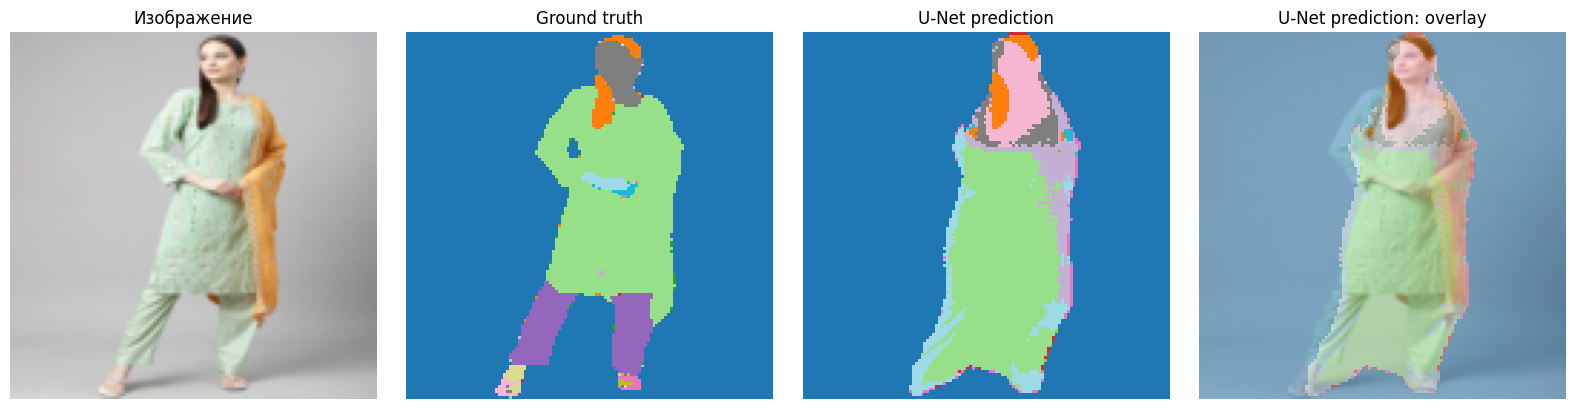

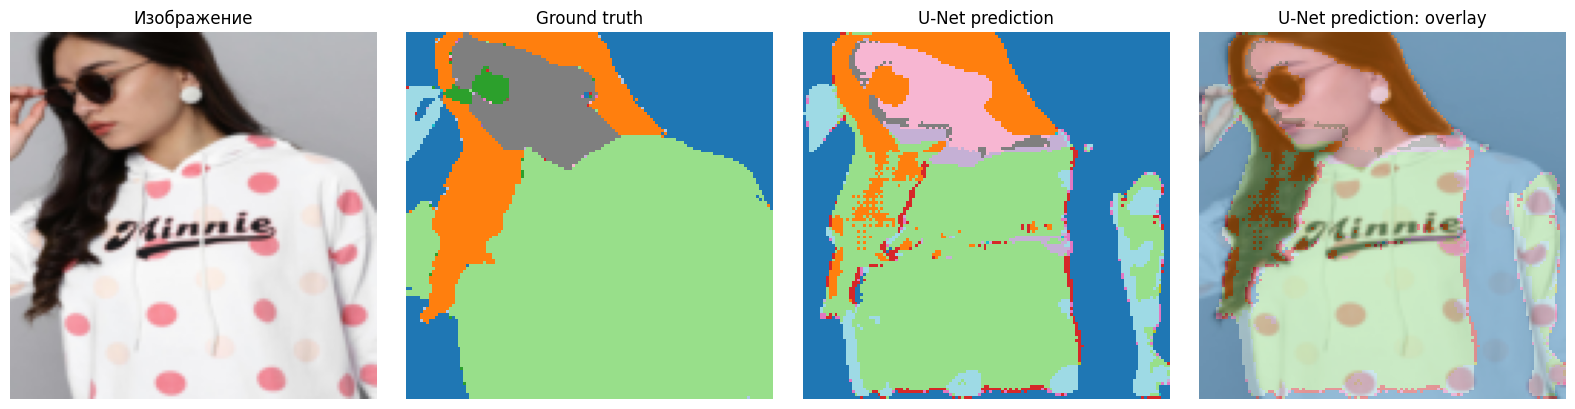

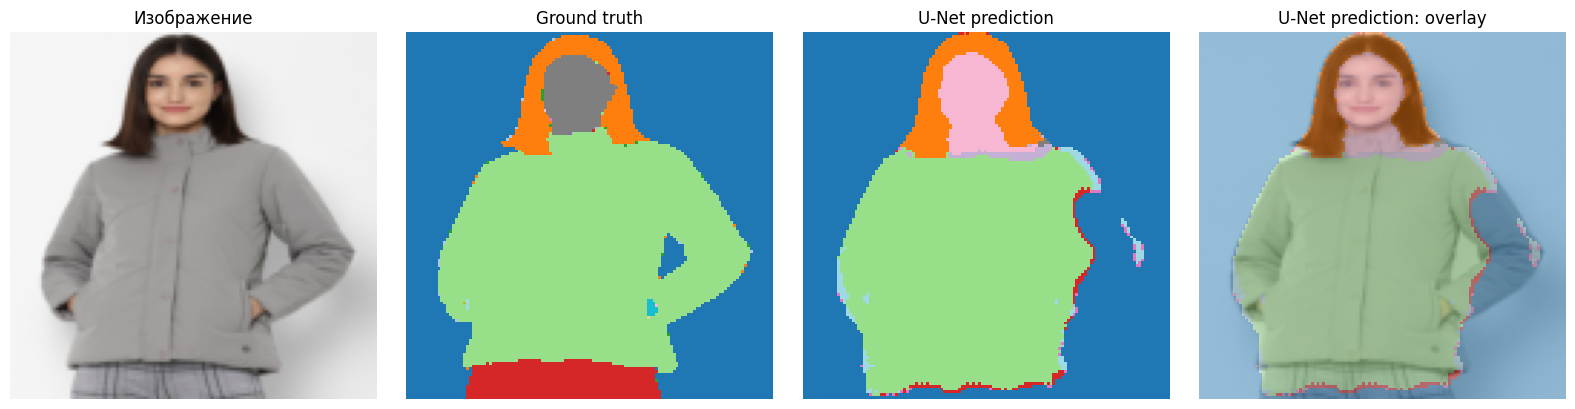

In [11]:
def visualize_segmentation_predictions(model, loader, n_classes, device=DEVICE, n=3, title="U-Net"):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in loader:
            images_device = images.to(device)
            targets = squeeze_masks(masks).to(device)
            preds = model(images_device).argmax(dim=1)

            for i in range(images.size(0)):
                image = images[i].permute(1, 2, 0).numpy()
                true_mask = targets[i].cpu().numpy()
                pred_mask = preds[i].cpu().numpy()

                fig, axes = plt.subplots(1, 4, figsize=(16, 4))
                axes[0].imshow(np.clip(image, 0, 1))
                axes[0].set_title("Изображение")
                axes[1].imshow(true_mask, cmap="tab20", vmin=0, vmax=n_classes - 1,
                               interpolation="nearest")
                axes[1].set_title("Ground truth")
                axes[2].imshow(pred_mask, cmap="tab20", vmin=0, vmax=n_classes - 1,
                               interpolation="nearest")
                axes[2].set_title(title)
                axes[3].imshow(np.clip(image, 0, 1))
                axes[3].imshow(pred_mask, cmap="tab20", vmin=0, vmax=n_classes - 1,
                               alpha=0.45, interpolation="nearest")
                axes[3].set_title(f"{title}: overlay")

                for ax in axes:
                    ax.axis("off")
                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= n:
                    return


if trained_unet is not None and test_loader is not None:
    visualize_segmentation_predictions(
        trained_unet,
        test_loader,
        n_classes=training_dataset.n_classes,
        n=3,
        title="U-Net prediction",
    )
else:
    print("Сначала выполните обучение U-Net.")


<p class="task" id="5"></p>

5\.  Обучите модуль `SegformerForSemanticSegmentation` из пакета `transformers` для сегментации изображения. Во время обучения выводите на экран значения функции потерь и точности прогнозов на обучающем и валидационном множестве. Для оптимизации используйте значение функции потерь, которое возвращает вам модель.

Используя обученную модель, получите предсказания для нескольких изображений и отрисуйте их.
- [ ] Проверено на семинаре

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([16])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([16, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Загружен pretrained SegFormer-B0: nvidia/segformer-b0-finetuned-ade-512-512
Epoch 01/100 | train loss=2.6220, acc=0.2462, mIoU=0.0428 | val loss=2.3357, acc=0.5739, mIoU=0.0895
Epoch 02/100 | train loss=2.2865, acc=0.5741, mIoU=0.0920 | val loss=1.9719, acc=0.6502, mIoU=0.0964
Epoch 03/100 | train loss=2.0161, acc=0.6363, mIoU=0.1029 | val loss=1.7553, acc=0.6735, mIoU=0.1069
Epoch 04/100 | train loss=1.8118, acc=0.6687, mIoU=0.1065 | val loss=1.6698, acc=0.6812, mIoU=0.1089
Epoch 05/100 | train loss=1.6655, acc=0.6920, mIoU=0.1152 | val loss=1.5274, acc=0.7095, mIoU=0.1236
Epoch 06/100 | train loss=1.5431, acc=0.6980, mIoU=0.1170 | val loss=1.4283, acc=0.7208, mIoU=0.1302
Epoch 07/100 | train loss=1.4230, acc=0.7202, mIoU=0.1275 | val loss=1.3456, acc=0.7435, mIoU=0.1425
Epoch 08/100 | train loss=1.3231, acc=0.7399, mIoU=0.1427 | val loss=1.2707, acc=0.7417, mIoU=0.1396
Epoch 09/100 | train loss=1.2267, acc=0.7541, mIoU=0.1488 | val loss=1.2047, acc=0.7491, mIoU=0.1446
Epoch 10/100 | 

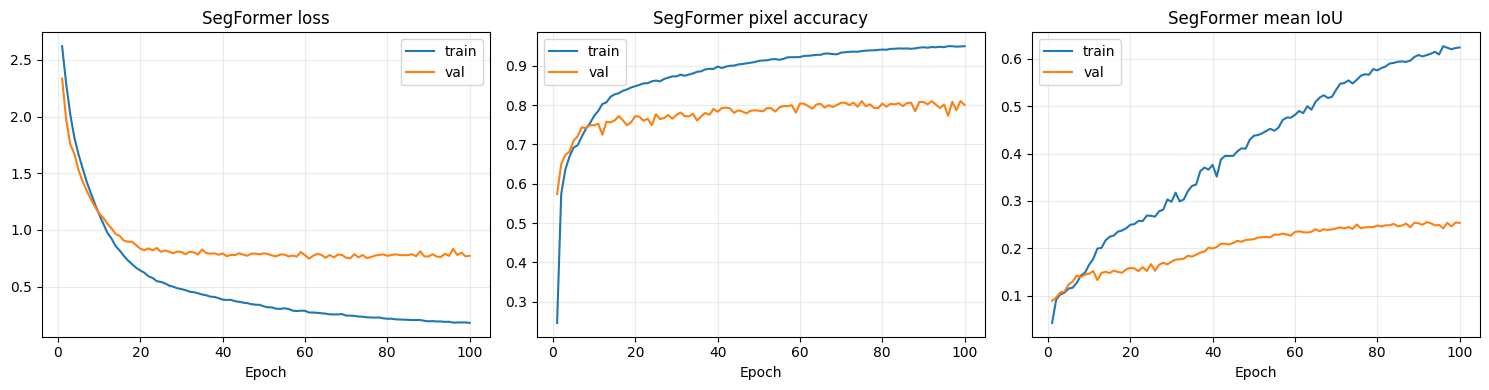

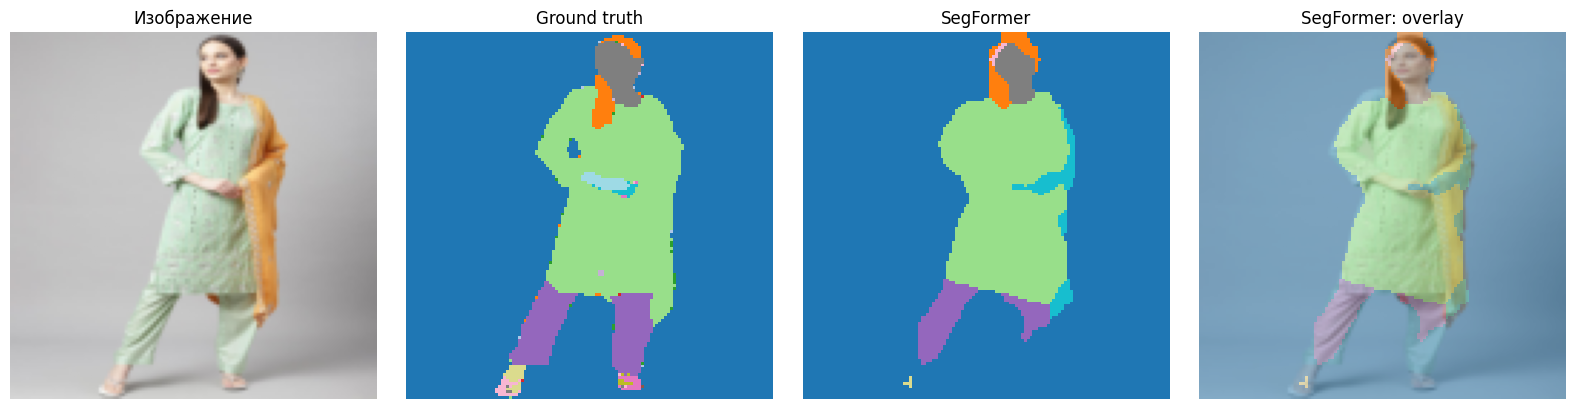

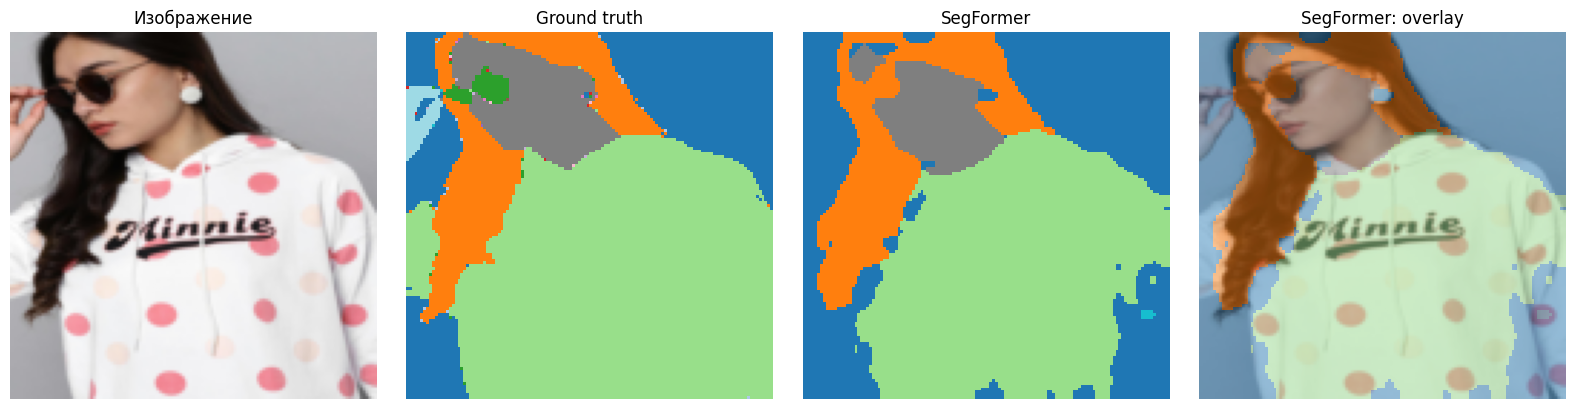

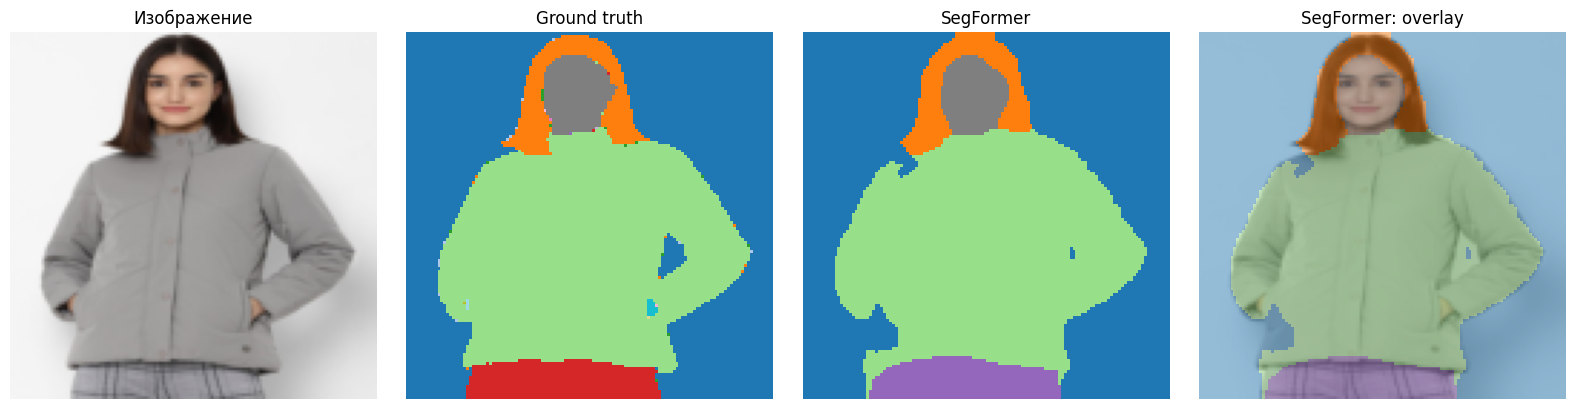

In [16]:
TRANSFORMERS_AVAILABLE = importlib.util.find_spec("transformers") is not None

if TRANSFORMERS_AVAILABLE:
    from transformers import SegformerConfig, SegformerForSemanticSegmentation
else:
    print(
        "Пакет transformers не установлен. "
    )


def normalize_for_segformer(images):
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    return (images - mean) / std


def run_segformer_epoch(model, loader, n_classes, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    loss_sum = 0.0
    conf = torch.zeros((n_classes, n_classes), dtype=torch.float64)

    for images, masks in loader:
        labels = squeeze_masks(masks).to(DEVICE)
        pixel_values = normalize_for_segformer(images.to(DEVICE))

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        logits = F.interpolate(
            outputs.logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        preds = logits.argmax(dim=1)

        loss_sum += loss.item() * images.size(0)
        conf += confusion_matrix_from_batch(preds, labels, n_classes)

    acc, miou = metrics_from_confusion(conf)
    return loss_sum / len(loader.dataset), acc, miou


def train_segformer(model, train_loader, val_loader, n_classes, epochs=100):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
    history = {k: [] for k in (
        "train_loss", "val_loss", "train_acc", "val_acc", "train_miou", "val_miou"
    )}
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_miou = run_segformer_epoch(
            model, train_loader, n_classes, optimizer
        )
        with torch.no_grad():
            val_loss, val_acc, val_miou = run_segformer_epoch(
                model, val_loader, n_classes
            )

        values = {
            "train_loss": train_loss, "val_loss": val_loss,
            "train_acc": train_acc, "val_acc": val_acc,
            "train_miou": train_miou, "val_miou": val_miou,
        }
        for k, v in values.items():
            history[k].append(v)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_loss:.4f}, acc={train_acc:.4f}, mIoU={train_miou:.4f} | "
            f"val loss={val_loss:.4f}, acc={val_acc:.4f}, mIoU={val_miou:.4f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_segformer.pth")

    return model, history


def create_segformer(n_classes):
    checkpoint = "nvidia/segformer-b0-finetuned-ade-512-512"
    id2label = {i: f"class_{i}" for i in range(n_classes)}
    label2id = {v: k for k, v in id2label.items()}

    try:
        model = SegformerForSemanticSegmentation.from_pretrained(
            checkpoint,
            num_labels=n_classes,
            ignore_mismatched_sizes=True,
            id2label=id2label,
            label2id=label2id,
        )
        print("Загружен pretrained SegFormer-B0:", checkpoint)
        return model
    except Exception as exc:
        print("Pretrained checkpoint недоступен; создаю SegFormer-B0 с нуля.")
        print("Причина:", str(exc)[:250])
        config = SegformerConfig(
            num_labels=n_classes,
            depths=[2, 2, 2, 2],
            hidden_sizes=[32, 64, 160, 256],
            decoder_hidden_size=256,
            id2label=id2label,
            label2id=label2id,
        )
        return SegformerForSemanticSegmentation(config)


def visualize_segformer_predictions(model, loader, n_classes, n=3):
    model.eval()
    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            labels = squeeze_masks(masks)
            outputs = model(pixel_values=normalize_for_segformer(images.to(DEVICE)))
            logits = F.interpolate(
                outputs.logits,
                size=labels.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )
            preds = logits.argmax(dim=1).cpu()

            for i in range(images.size(0)):
                image = images[i].permute(1, 2, 0).numpy()
                fig, axes = plt.subplots(1, 4, figsize=(16, 4))
                axes[0].imshow(image)
                axes[0].set_title("Изображение")
                axes[1].imshow(labels[i].numpy(), cmap="tab20", vmin=0, vmax=n_classes - 1,
                               interpolation="nearest")
                axes[1].set_title("Ground truth")
                axes[2].imshow(preds[i].numpy(), cmap="tab20", vmin=0, vmax=n_classes - 1,
                               interpolation="nearest")
                axes[2].set_title("SegFormer")
                axes[3].imshow(image)
                axes[3].imshow(preds[i].numpy(), cmap="tab20", vmin=0, vmax=n_classes - 1,
                               alpha=0.45, interpolation="nearest")
                axes[3].set_title("SegFormer: overlay")
                for ax in axes:
                    ax.axis("off")
                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= n:
                    return


segformer_model = None
segformer_history = None

if archive_train_dataset is not None and TRANSFORMERS_AVAILABLE:
    if train_loader is None or val_loader is None:
        raise RuntimeError("Сначала выполните задание 4 и создайте train_loader/val_loader")

    n_classes = archive_train_dataset.n_classes
    segformer_model = create_segformer(n_classes)
    segformer_model, segformer_history = train_segformer(
        segformer_model, train_loader, val_loader, n_classes, epochs=100
    )

    segformer_model.load_state_dict(torch.load(
        "best_segformer.pth", map_location=DEVICE, weights_only=True
    ))

    with torch.no_grad():
        test_loss, test_acc, test_miou = run_segformer_epoch(
            segformer_model, test_loader, n_classes
        )
    print(
        f"SEGFORMER TEST | loss={test_loss:.4f}, "
        f"acc={test_acc:.4f}, mIoU={test_miou:.4f}"
    )

    epochs_axis = np.arange(1, len(segformer_history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs_axis, segformer_history["train_loss"], label="train")
    axes[0].plot(epochs_axis, segformer_history["val_loss"], label="val")
    axes[0].set_title("SegFormer loss")

    axes[1].plot(epochs_axis, segformer_history["train_acc"], label="train")
    axes[1].plot(epochs_axis, segformer_history["val_acc"], label="val")
    axes[1].set_title("SegFormer pixel accuracy")

    axes[2].plot(epochs_axis, segformer_history["train_miou"], label="train")
    axes[2].plot(epochs_axis, segformer_history["val_miou"], label="val")
    axes[2].set_title("SegFormer mean IoU")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()

    visualize_segformer_predictions(segformer_model, test_loader, n_classes, n=3)
elif archive_train_dataset is None:
    print("Архив People Clothing Segmentation не найден — обучение SegFormer пропущено.")


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ